# Chapter 2: Projective Planes

**Source span read.** Perspectives on Projective Geometry, Chapter 2, sections 2.1-2.3; printed pages 35-46; PDF pages 57-68.

**Chapter goal.** Build a working incidence model of a projective plane: perspective drawings preserve point-line incidence, parallel Euclidean lines acquire ideal intersection points, the point and line axioms are dual, and the Fano plane is the smallest finite model.

The chapter starts from a practical observation about perspective drawing: a line in space usually becomes a line on the canvas, and a point on that line remains incident with the image line. It then abstracts away from measurements and keeps only incidence. The notebook follows that route computationally. We make synthetic drawings, but every drawing is backed by a table or check so a near miss in the picture is not mistaken for a theorem.

In [1]:
from pathlib import Path
import sys

START = Path.cwd().resolve()
BOOK_ROOT = None
for candidate in [START, *START.parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "Perspectives on Projective Geometry.pdf").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not discover the Perspectives on Projective Geometry course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "chapter-02-projective-planes"
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
TABLES = ARTIFACT_ROOT / "tables"
CHECKS = ARTIFACT_ROOT / "checks"
for folder in (FIGURES, HTML, TABLES, CHECKS):
    folder.mkdir(parents=True, exist_ok=True)

ARTIFACT_ROOT.relative_to(BOOK_ROOT).as_posix()

'artifacts/chapter-02-projective-planes'

## Computational Translation Guide

| Chapter language | Computational representation in this notebook | Check that makes it geometric |
| --- | --- | --- |
| Perspective drawing | Central projection from an eye point to a canvas | projected samples have zero point-line residual |
| Incidence relation `I` | a table saying which point labels lie on which line labels | every selected incidence is verified by membership or dot product |
| Join of two points | the unique line containing a pair | every unordered point pair appears in exactly one line |
| Meet of two lines | the unique point shared by a pair | every unordered line pair intersects in exactly one point |
| Point at infinity | one added point for a parallel direction class | all representatives of that class use the same ideal label |
| Duality | swap the roles of point rows and line columns | the transposed incidence table satisfies the same pair counts |
| Finite projective plane of order `n` | a finite incidence table with `n + 1` points per line | total point and line counts equal `n^2 + n + 1` |

The main discipline is to separate visual position from incidence. A Fano plane line may be drawn as a curve in the figure below, but it is still just a three-point line in the incidence table. Conversely, two drawn strokes that look close do not meet unless the table or algebra says they meet.

In [2]:
from itertools import combinations
import math
import os

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go

from utils.artifacts import assert_artifacts, book_relative, display_artifact, image_stats, save_json
from utils.projective import join, meet

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160, "font.size": 10})

DISPLAY_ARTIFACTS = []
TABLE_ARTIFACTS = []
CHECK_RECORD = {}

def save_figure(fig, filename):
    path = FIGURES / filename
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    DISPLAY_ARTIFACTS.append(path)
    return path

def display_chapter_artifact(path, **kwargs):
    relative = Path(os.path.relpath(Path(path), Path.cwd()))
    return display_artifact(relative, **kwargs)

def h2(x, y):
    return np.array([float(x), float(y), 1.0])

def dehom(point):
    point = np.asarray(point, dtype=float)
    if abs(point[-1]) < 1e-12:
        raise ValueError("point at infinity has no affine chart coordinates")
    return point[:-1] / point[-1]

def line_residual(point, line):
    line = np.asarray(line, dtype=float)
    scale = max(np.linalg.norm(line[:2]), 1.0)
    return float(abs(np.dot(point, line)) / scale)

def project_to_canvas(point, eye_x=0.0, canvas_z=1.0):
    eye = np.array([eye_x, 0.0, 0.0], dtype=float)
    point = np.asarray(point, dtype=float)
    if abs(point[2] - eye[2]) < 1e-12:
        raise ValueError("projection ray is parallel to the canvas")
    t = (canvas_z - eye[2]) / (point[2] - eye[2])
    hit = eye + t * (point - eye)
    return np.array([hit[0], hit[1], 1.0], dtype=float)

def plot_image_line(ax, p0, p1, **kwargs):
    a = dehom(p0)
    b = dehom(p1)
    ax.plot([a[0], b[0]], [a[1], b[1]], **kwargs)

def circle_through(a, b, c):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    c = np.asarray(c, dtype=float)
    matrix = np.array([
        [2 * (b[0] - a[0]), 2 * (b[1] - a[1])],
        [2 * (c[0] - a[0]), 2 * (c[1] - a[1])],
    ])
    rhs = np.array([
        b[0] ** 2 + b[1] ** 2 - a[0] ** 2 - a[1] ** 2,
        c[0] ** 2 + c[1] ** 2 - a[0] ** 2 - a[1] ** 2,
    ])
    center = np.linalg.solve(matrix, rhs)
    return center, float(np.linalg.norm(a - center))

def incidence_counts(points, lines):
    point_counts = {p: 0 for p in points}
    for line_points in lines.values():
        for p in line_points:
            point_counts[p] += 1
    return point_counts

def one_line_per_point_pair(points, lines):
    failures = []
    for a, b in combinations(points, 2):
        containing = [name for name, line_points in lines.items() if a in line_points and b in line_points]
        if len(containing) != 1:
            failures.append((a, b, containing))
    return failures

def one_point_per_line_pair(lines):
    failures = []
    for left, right in combinations(lines, 2):
        shared = sorted(set(lines[left]).intersection(lines[right]))
        if len(shared) != 1:
            failures.append((left, right, shared))
    return failures

## Visualization Planner Pass

The source span suggests five inspectable objects: the central projection mechanism, the added line at infinity, the incidence axioms and their proof dependencies, point-line duality, and the Fano plane. The routing is intentionally mixed: Matplotlib gives durable labelled incidence diagrams, NetworkX exposes proof dependency rather than a decorative graph, Plotly supplies a small parameter lab for the eye point, and pandas/CSV records the point-line tables used in the finite-plane checks.

In [3]:
STORYBOARD = {
    "chapter goal": "Build a standalone incidence model of projective planes, from perspective drawings to the Fano plane.",
    "source span read": "printed pages 35-46; PDF pages 57-68; sections 2.1-2.3",
    "concept inventory": [
        "perspective drawing as central projection that preserves point-line incidence",
        "parallel Euclidean directions represented by ideal points on one line at infinity",
        "projective plane as a triple (P, L, I) with unique joins, unique meets, and nondegeneracy",
        "point-line duality by transposing incidence data",
        "Fano plane as the seven-point smallest finite projective plane",
        "finite projective plane order n with n + 1 points per line and n^2 + n + 1 total points and lines",
    ],
    "library routing table": [
        {"concept": "central projection and vanishing point", "representation": "synthetic perspective diagram plus residual checks", "library": "numpy and matplotlib", "why": "precise 2D incidence drawings with labelled residuals", "fallback": "static SVG generated from the same coordinates"},
        {"concept": "parameter variation in the viewpoint", "representation": "interactive HTML lab", "library": "plotly", "why": "moving the eye point is easier to inspect as a slider than as several static panels", "fallback": "saved PNG perspective diagram and JSON residuals"},
        {"concept": "axiom and theorem dependencies", "representation": "directed proof dependency graph", "library": "networkx and matplotlib", "why": "the uniform-count proof is a dependency argument, not a metric picture", "fallback": "markdown dependency table"},
        {"concept": "Fano incidence and duality", "representation": "finite incidence table and matrix transpose", "library": "pandas, numpy, matplotlib", "why": "finite projective planes are most testable as point-line tables", "fallback": "plain CSV table"},
    ],
    "visual sequence": [
        {"concept": "perspective drawings as incidence", "artifact": "figures/perspective-incidence-projection.png", "learner inspection target": "line images pass through the same vanishing point while point-line residuals stay zero", "validation": "maximum projected point-line residual and vanishing residual"},
        {"concept": "Euclidean completion by ideal points", "artifact": "figures/line-at-infinity-completion.png", "learner inspection target": "each parallel class receives exactly one ideal point on the horizon line", "validation": "ideal points satisfy the horizon incidence equation"},
        {"concept": "incidence axioms and finite-count proof flow", "artifact": "figures/axiom-duality-proof-dependencies.png", "learner inspection target": "A1 and A2 are dual; A3 prevents collapse; finite counts depend on the lemmas", "validation": "dependency graph is acyclic after excluding the duality mirror arrow"},
        {"concept": "smallest finite projective plane", "artifact": "figures/fano-plane-smallest-model.png", "learner inspection target": "four starting points force three diagonal points and the final three-point line", "validation": "seven lines, seven points, three points per line, three lines per point"},
        {"concept": "point-line duality as a table transpose", "artifact": "figures/duality-incidence-transpose.png", "learner inspection target": "row and column counts agree and pair uniqueness survives transposition", "validation": "unique line per point pair and unique point per line pair"},
    ],
    "artifact plan": [
        "artifacts/chapter-02-projective-planes/figures/perspective-incidence-projection.png",
        "artifacts/chapter-02-projective-planes/figures/line-at-infinity-completion.png",
        "artifacts/chapter-02-projective-planes/figures/axiom-duality-proof-dependencies.png",
        "artifacts/chapter-02-projective-planes/figures/fano-plane-smallest-model.png",
        "artifacts/chapter-02-projective-planes/figures/duality-incidence-transpose.png",
        "artifacts/chapter-02-projective-planes/html/perspective-incidence-lab.html",
        "artifacts/chapter-02-projective-planes/tables/fano-line-table.csv",
        "artifacts/chapter-02-projective-planes/tables/fano-incidence-matrix.csv",
        "artifacts/chapter-02-projective-planes/tables/finite-plane-counts.csv",
        "artifacts/chapter-02-projective-planes/checks/finite-plane-sanity.json",
        "artifacts/chapter-02-projective-planes/checks/visual-checks.json",
        "artifacts/chapter-02-projective-planes/checks/final-sanity.json",
    ],
    "computational checks": [
        "central projection point-line residuals below 1e-10",
        "vanishing point lies on each projected parallel image line",
        "ideal points lie on the drawn line at infinity",
        "Fano point pairs determine one line and line pairs determine one point",
        "Fano counts satisfy n = 2 and n^2 + n + 1 = 7",
        "all generated artifacts exist and have nonzero size",
    ],
    "proof-visualization strategy": "Use a NetworkX dependency graph for Lemma 2.1 through Theorem 2.2 and a finite model checker for the Fano plane.",
    "implementation notes": "Notebook code is chapter-local. It avoids the generic render_chapter_visuals helper and writes only the chapter artifact subtree.",
    "risks": [
        "The curved Fano line is a drawing convention for an abstract incidence line, not a Euclidean circle theorem.",
        "The perspective lab is synthetic and uses no scanned or source-page images.",
    ],
    "acceptance criteria": [
        "nbclient execution for chapter 2 succeeds",
        "scoped notebook and visual audits pass for chapter 2",
        "git diff --check passes for the assigned notebook and artifact subtree",
    ],
}
storyboard_path = save_json(STORYBOARD, ARTIFACT_ROOT, "checks", "storyboard.json")
storyboard_path.relative_to(BOOK_ROOT).as_posix()

'artifacts/chapter-02-projective-planes/checks/storyboard.json'

## Perspective Drawings as Incidence

A central projection forgets lengths, angles, and parallelism, but it keeps incidence. In the synthetic scene below, several parallel object-space lines are projected onto a canvas. Their images are no longer parallel: they meet at a vanishing point. The check that matters is not whether the drawing looks plausible, but whether projected samples from each object-space line lie on the image line computed from its projected endpoints.

In [4]:
eye_x = 0.0
canvas_z = 1.0
rails = {
    "left depth line": (np.array([-1.35, -0.65, 1.0]), np.array([-1.35, -0.65, 6.0])),
    "center depth line": (np.array([0.0, -0.20, 1.0]), np.array([0.0, -0.20, 6.0])),
    "right depth line": (np.array([1.35, -0.65, 1.0]), np.array([1.35, -0.65, 6.0])),
    "roof edge": (np.array([-0.95, 0.75, 1.0]), np.array([-0.95, 0.75, 5.0])),
}
colors = ["#2c7fb8", "#41ab5d", "#f03b20", "#756bb1"]
vanishing = np.array([eye_x, 0.0, 1.0])

fig = plt.figure(figsize=(12, 5.4))
ax3 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2)

perspective_residuals = []
vanishing_residuals = []
for (name, (p0, p1)), color in zip(rails.items(), colors):
    projected_ends = [project_to_canvas(p0, eye_x, canvas_z), project_to_canvas(p1, eye_x, canvas_z)]
    image_line = join(projected_ends[0], projected_ends[1])
    samples = [p0 + t * (p1 - p0) for t in np.linspace(0.0, 1.0, 7)]
    perspective_residuals.extend(line_residual(project_to_canvas(sample, eye_x, canvas_z), image_line) for sample in samples)
    vanishing_residuals.append(line_residual(vanishing, image_line))
    ax3.plot([p0[0], p1[0]], [p0[2], p1[2]], [p0[1], p1[1]], color=color, lw=2.2, label=name)
    for endpoint in (p0, p1):
        hit = project_to_canvas(endpoint, eye_x, canvas_z)
        ax3.plot([eye_x, hit[0], endpoint[0]], [0.0, canvas_z, endpoint[2]], [0.0, hit[1], endpoint[1]], color=color, alpha=0.22, lw=0.9)
    plot_image_line(ax2, projected_ends[0], projected_ends[1], color=color, lw=2.4, label=name)
    endpoint_xy = np.vstack([dehom(projected_ends[0]), dehom(projected_ends[1])])
    ax2.scatter(endpoint_xy[:, 0], endpoint_xy[:, 1], color=color, s=18)

xx = np.linspace(-1.6, 1.6, 2)
yy = np.linspace(-0.85, 0.9, 2)
XX, YY = np.meshgrid(xx, yy)
ZZ = np.full_like(XX, canvas_z)
ax3.plot_surface(XX, ZZ, YY, color="#f7f7f7", edgecolor="#bdbdbd", alpha=0.45)
ax3.scatter([eye_x], [0.0], [0.0], marker="*", s=90, color="black", label="eye")
ax3.set_title("Object-space lines and projection rays")
ax3.set_xlabel("x")
ax3.set_ylabel("depth z")
ax3.set_zlabel("image y")
ax3.view_init(elev=18, azim=-55)
ax3.legend(loc="upper left", fontsize=8)

ax2.scatter([dehom(vanishing)[0]], [dehom(vanishing)[1]], marker="x", s=80, color="black", zorder=4)
ax2.annotate("common vanishing point", xy=dehom(vanishing), xytext=(0.12, 0.28), arrowprops={"arrowstyle": "->", "lw": 1.0})
ax2.axhline(0, color="#d9d9d9", lw=0.8)
ax2.axvline(0, color="#d9d9d9", lw=0.8)
ax2.set_title("Canvas image: incidence survives, parallelism does not")
ax2.set_xlabel("canvas x")
ax2.set_ylabel("canvas y")
ax2.set_aspect("equal", adjustable="box")
ax2.legend(loc="lower right", fontsize=8)
fig.suptitle("Perspective drawing as checked point-line incidence", y=1.02, fontsize=13)

perspective_png = save_figure(fig, "perspective-incidence-projection.png")
CHECK_RECORD["perspective_projection"] = {
    "max_projected_point_line_residual": float(max(perspective_residuals)),
    "max_vanishing_point_residual": float(max(vanishing_residuals)),
    "projected_line_count": len(rails),
    "parallel_object_direction": [0.0, 0.0, 1.0],
}
perspective_png.relative_to(BOOK_ROOT).as_posix(), CHECK_RECORD["perspective_projection"]

('artifacts/chapter-02-projective-planes/figures/perspective-incidence-projection.png',
 {'max_projected_point_line_residual': 1.1102230246251565e-16,
  'max_vanishing_point_residual': 0.0,
  'projected_line_count': 4,
  'parallel_object_direction': [0.0, 0.0, 1.0]})

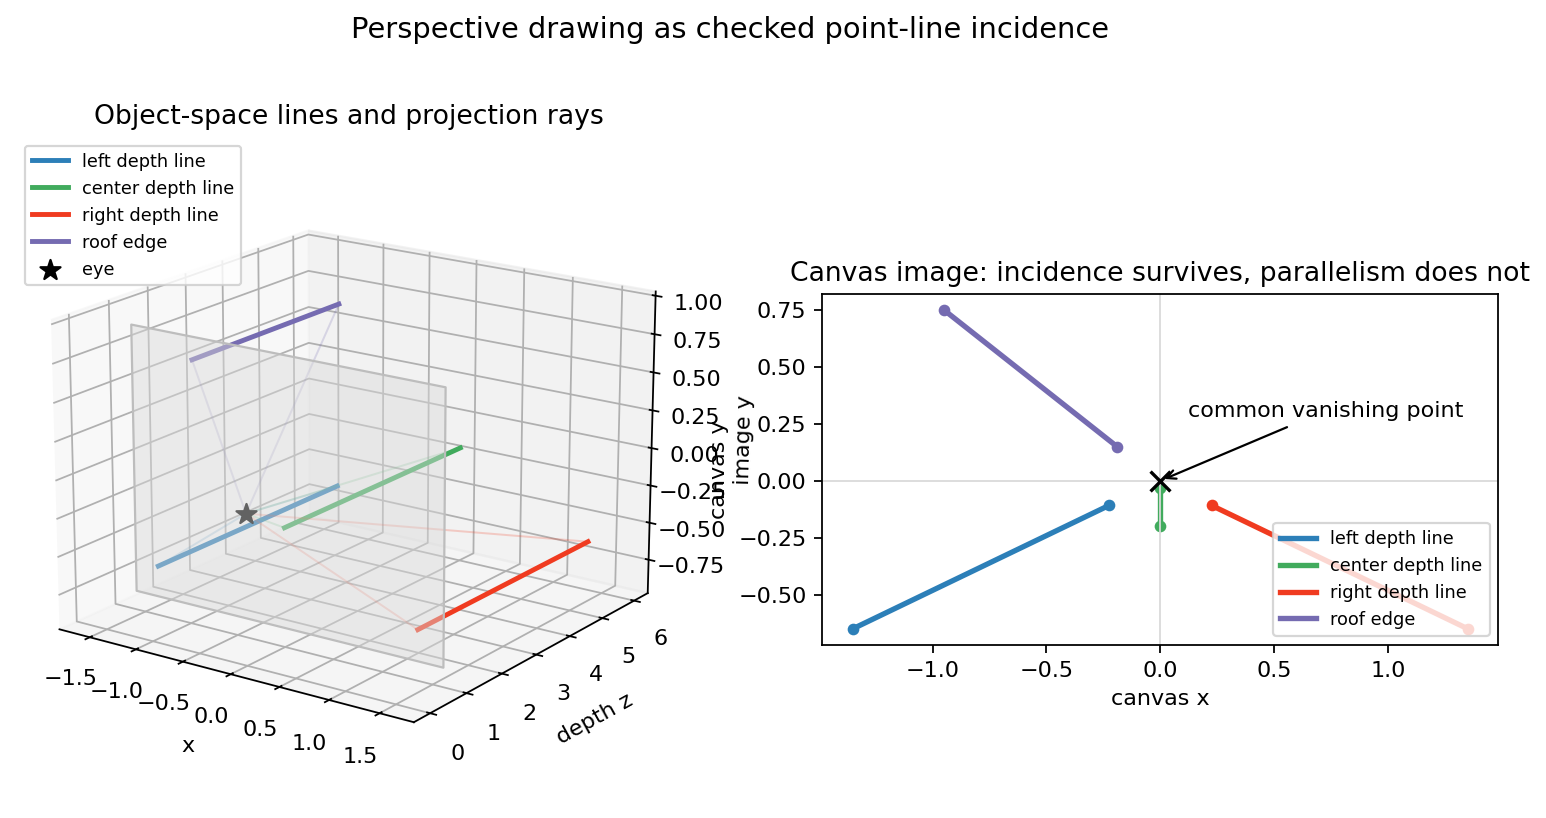

In [5]:
display_chapter_artifact(perspective_png, width=820)

## Adding the Line at Infinity

The projective extension of the Euclidean plane replaces the phrase "parallel lines do not meet" with a data rule: each parallel class receives one ideal point, and all ideal points lie on one added line. The horizontal line in the artifact is only a drawing device for this notebook's affine chart. The incidence idea is the important part: many Euclidean representatives, one ideal point for their shared direction.

In [6]:
fig, ax = plt.subplots(figsize=(9.2, 5.8))
horizon_y = 2.35
ax.axhline(horizon_y, color="black", lw=2.0)
ax.text(-2.15, horizon_y + 0.08, "line at infinity", fontsize=10, weight="bold")
families = [
    {"name": "slope 0", "kind": "slope", "m": 0.0, "bs": [-1.0, -0.25, 0.55], "ideal": (-1.55, horizon_y), "color": "#1f78b4"},
    {"name": "slope 0.75", "kind": "slope", "m": 0.75, "bs": [-1.25, -0.35, 0.55], "ideal": (-0.35, horizon_y), "color": "#33a02c"},
    {"name": "slope -1.1", "kind": "slope", "m": -1.1, "bs": [-0.75, 0.1, 0.95], "ideal": (0.85, horizon_y), "color": "#e31a1c"},
    {"name": "vertical", "kind": "vertical", "xs": [-1.4, -0.15, 1.25], "ideal": (1.75, horizon_y), "color": "#6a3d9a"},
]
ideal_residuals = []
horizon_line = np.array([0.0, 1.0, -horizon_y])
for family in families:
    color = family["color"]
    ix, iy = family["ideal"]
    ax.scatter([ix], [iy], s=70, color=color, edgecolor="black", zorder=5)
    ax.text(ix, iy + 0.15, f"p[{family['name']}]", ha="center", color=color, fontsize=9)
    ideal_residuals.append(line_residual(h2(ix, iy), horizon_line))
    if family["kind"] == "slope":
        xs = np.linspace(-2.05, 2.05, 100)
        for b in family["bs"]:
            ys = family["m"] * xs + b
            visible = (ys > -1.65) & (ys < 1.75)
            ax.plot(xs[visible], ys[visible], color=color, lw=1.5, alpha=0.9)
            ax.plot([xs[visible][-1], ix], [ys[visible][-1], iy], color=color, lw=0.8, alpha=0.35, ls="--")
    else:
        for x in family["xs"]:
            ax.plot([x, x], [-1.55, 1.65], color=color, lw=1.5, alpha=0.9)
            ax.plot([x, ix], [1.65, iy], color=color, lw=0.8, alpha=0.35, ls="--")
ax.text(-2.12, -1.88, "Euclidean representatives stay ordinary lines; the extension records their missing intersections by direction class.", fontsize=9)
ax.set_xlim(-2.25, 2.25)
ax.set_ylim(-2.05, 2.75)
ax.set_aspect("equal", adjustable="box")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Projective completion: one ideal point for each parallel class")
for spine in ax.spines.values():
    spine.set_visible(False)
line_infinity_png = save_figure(fig, "line-at-infinity-completion.png")
CHECK_RECORD["line_at_infinity"] = {
    "parallel_class_count": len(families),
    "ideal_points_on_horizon": all(res < 1e-12 for res in ideal_residuals),
    "max_horizon_residual": float(max(ideal_residuals)),
}
line_infinity_png.relative_to(BOOK_ROOT).as_posix(), CHECK_RECORD["line_at_infinity"]

('artifacts/chapter-02-projective-planes/figures/line-at-infinity-completion.png',
 {'parallel_class_count': 4,
  'ideal_points_on_horizon': True,
  'max_horizon_residual': 0.0})

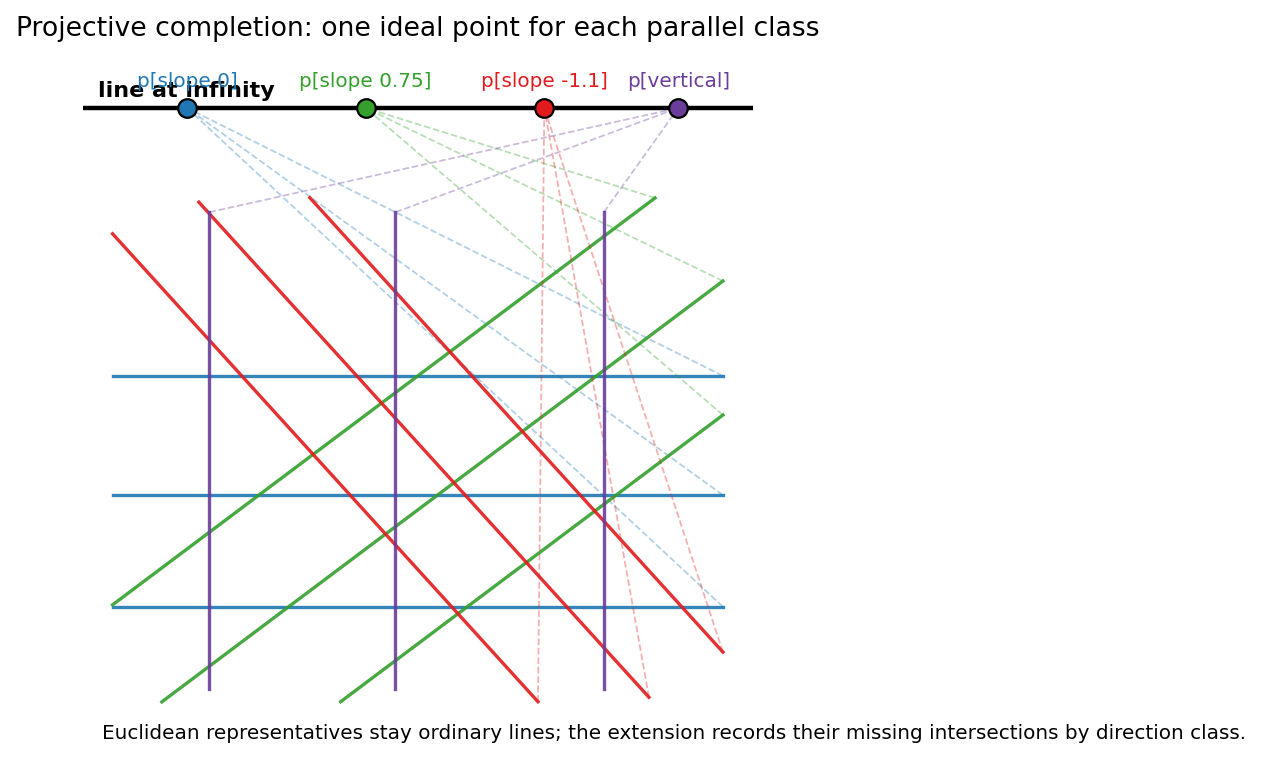

In [7]:
display_chapter_artifact(line_infinity_png, width=760)

## Axioms, Duality, and the Counting Proof

The definition of a projective plane keeps three ingredients: points, lines, and an incidence relation. Axiom A1 says two distinct points determine one line. Axiom A2 says two distinct lines determine one point. Axiom A3 rules out collapsed structures by requiring four points with no three on a line. The first two axioms are exact duals of each other, so a proof that only uses the incidence pattern often has a dual version obtained by swapping the words point and line.

The dependency graph records how the finite-plane counting results are scaffolded. Lemma 2.1 blocks two distinct points from sharing two distinct lines. That "no double incidence" fact is the small invariant that lets the later counting proof avoid overcounting.

In [8]:
dependency_edges = [
    ("A1: unique join", "Lemma: no double incidence"),
    ("A2: unique meet", "Lemma: no double incidence"),
    ("A3: nondegenerate four points", "Lemma: each line has >= 3 points"),
    ("Lemma: no double incidence", "Lemma: each line has >= 3 points"),
    ("Lemma: each line has >= 3 points", "Lemma: line avoiding a point"),
    ("Lemma: line avoiding a point", "Theorem: uniform n + 1 counts"),
    ("Lemma: no double incidence", "Theorem: uniform n + 1 counts"),
    ("Theorem: uniform n + 1 counts", "Theorem: |P| = |L| = n^2 + n + 1"),
    ("Lemma: no double incidence", "Theorem: |P| = |L| = n^2 + n + 1"),
]
G = nx.DiGraph(dependency_edges)
positions = {
    "A1: unique join": (-1.9, 1.2),
    "A2: unique meet": (1.9, 1.2),
    "A3: nondegenerate four points": (0.0, 1.65),
    "Lemma: no double incidence": (0.0, 0.55),
    "Lemma: each line has >= 3 points": (-1.25, -0.15),
    "Lemma: line avoiding a point": (1.25, -0.15),
    "Theorem: uniform n + 1 counts": (0.0, -0.95),
    "Theorem: |P| = |L| = n^2 + n + 1": (0.0, -1.72),
}
node_colors = ["#fee8c8" if node.startswith("A") else "#d9f0d3" if node.startswith("Theorem") else "#deebf7" for node in G.nodes]
fig, ax = plt.subplots(figsize=(10.4, 7.0))
nx.draw_networkx_edges(G, positions, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=16, width=1.35, edge_color="#636363")
nx.draw_networkx_nodes(G, positions, ax=ax, node_size=2650, node_color=node_colors, edgecolors="#525252", linewidths=1.0)
nx.draw_networkx_labels(G, positions, ax=ax, font_size=8.3)
ax.annotate("duality mirror: swap points and lines", xy=(-1.55, 1.2), xytext=(1.55, 1.2), ha="center", va="center", arrowprops={"arrowstyle": "<->", "lw": 1.6, "color": "#8856a7"}, color="#8856a7", fontsize=9)
ax.text(-2.28, -2.18, "The purple mirror is not a proof dependency; it marks the point-line duality of A1 and A2.", fontsize=9)
ax.set_axis_off()
ax.set_title("Incidence axioms and the finite-plane count proof scaffold")
axiom_png = save_figure(fig, "axiom-duality-proof-dependencies.png")
CHECK_RECORD["axiom_dependency_graph"] = {
    "node_count": G.number_of_nodes(),
    "edge_count": G.number_of_edges(),
    "dependency_graph_acyclic": bool(nx.is_directed_acyclic_graph(G)),
    "dual_axiom_pair": ["A1: unique join", "A2: unique meet"],
}
axiom_png.relative_to(BOOK_ROOT).as_posix(), CHECK_RECORD["axiom_dependency_graph"]

('artifacts/chapter-02-projective-planes/figures/axiom-duality-proof-dependencies.png',
 {'node_count': 8,
  'edge_count': 9,
  'dependency_graph_acyclic': True,
  'dual_axiom_pair': ['A1: unique join', 'A2: unique meet']})

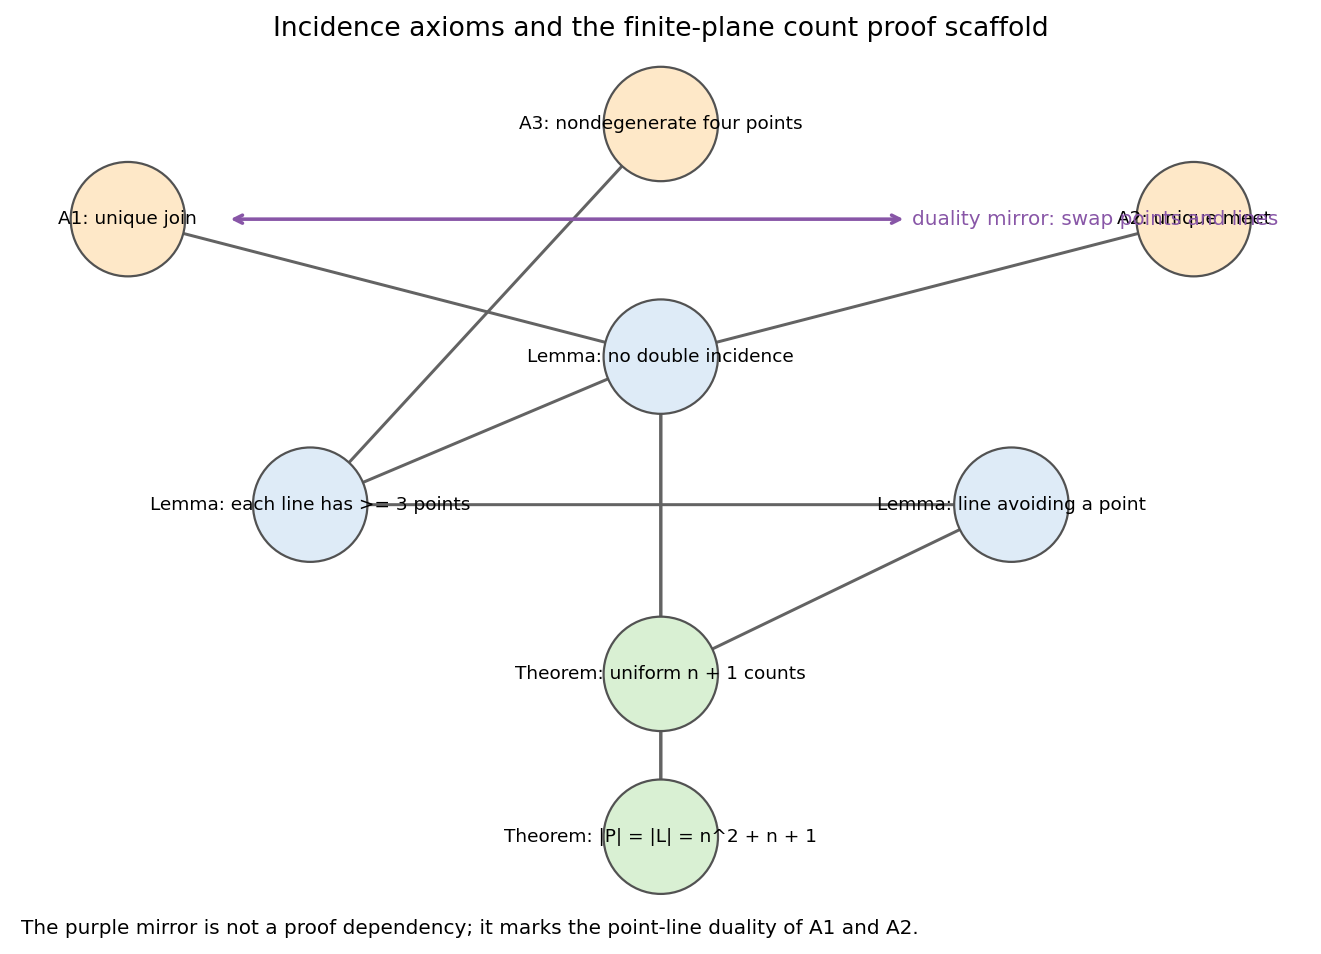

In [9]:
display_chapter_artifact(axiom_png, width=780)

## The Fano Plane: The Smallest Finite Projective Plane

Axiom A3 forces at least four points with no three collinear. Starting with four such points, the join axiom gives six lines. Opposite pairs of those six lines create three more intersection points. The meet axiom then forces one more line through those three new points. The result has seven points and seven lines: the Fano plane.

In the drawing, the curved stroke through `D`, `E`, and `F` is a visual convention for one abstract line. The incidence table immediately below is the actual model.

In [10]:
base_positions = {
    "A": np.array([0.0, 1.2]),
    "B": np.array([-1.2, -0.8]),
    "C": np.array([1.2, -0.8]),
    "G": np.array([0.0, 0.0]),
}

def intersect_drawn_lines(p, q, r, s):
    return dehom(meet(join(h2(*p), h2(*q)), join(h2(*r), h2(*s))))

point_positions = dict(base_positions)
point_positions["D"] = intersect_drawn_lines(base_positions["A"], base_positions["B"], base_positions["C"], base_positions["G"])
point_positions["E"] = intersect_drawn_lines(base_positions["A"], base_positions["C"], base_positions["B"], base_positions["G"])
point_positions["F"] = intersect_drawn_lines(base_positions["A"], base_positions["G"], base_positions["B"], base_positions["C"])

FANO_POINTS = ["A", "B", "C", "D", "E", "F", "G"]
FANO_LINES = {
    "l_ABD": ("A", "B", "D"),
    "l_ACE": ("A", "C", "E"),
    "l_BCF": ("B", "C", "F"),
    "l_AGF": ("A", "G", "F"),
    "l_BEG": ("B", "E", "G"),
    "l_CDG": ("C", "D", "G"),
    "l_DEF": ("D", "E", "F"),
}
line_colors = {"l_ABD": "#1b9e77", "l_ACE": "#1b9e77", "l_BCF": "#1b9e77", "l_AGF": "#7570b3", "l_BEG": "#7570b3", "l_CDG": "#7570b3", "l_DEF": "#d95f02"}
fig, ax = plt.subplots(figsize=(7.4, 7.2))
for line_name, line_points in FANO_LINES.items():
    color = line_colors[line_name]
    coords = np.array([point_positions[p] for p in line_points])
    if line_name == "l_DEF":
        center, radius = circle_through(coords[0], coords[1], coords[2])
        ax.add_patch(Circle(center, radius, fill=False, color=color, lw=2.0))
        ax.text(center[0], center[1] - radius - 0.12, line_name, color=color, ha="center", fontsize=8)
    else:
        order = sorted(line_points, key=lambda p: point_positions[p][0] + 0.2 * point_positions[p][1])
        coords = np.array([point_positions[p] for p in order])
        ax.plot(coords[:, 0], coords[:, 1], color=color, lw=2.0, alpha=0.92)
        mid = coords.mean(axis=0)
        ax.text(mid[0], mid[1] + 0.08, line_name, color=color, ha="center", fontsize=8)
for point in FANO_POINTS:
    x, y = point_positions[point]
    is_initial = point in {"A", "B", "C", "G"}
    ax.scatter([x], [y], s=115 if is_initial else 95, color="#fff7bc" if is_initial else "#c7e9b4", edgecolor="black", zorder=5)
    ax.text(x, y + 0.12, point, ha="center", va="bottom", weight="bold")
ax.text(-1.55, 1.43, "initial noncollinear set: A, B, C, G", fontsize=9, color="#525252")
ax.text(-1.55, -1.28, "D, E, F are forced intersections; l_DEF closes the plane", fontsize=9, color="#525252")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.65, 1.65)
ax.set_ylim(-1.55, 1.65)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Fano plane as the seven-point completion forced by incidence")
for spine in ax.spines.values():
    spine.set_visible(False)
fano_png = save_figure(fig, "fano-plane-smallest-model.png")

incidence_matrix = pd.DataFrame(0, index=FANO_POINTS, columns=FANO_LINES.keys(), dtype=int)
for line_name, line_points in FANO_LINES.items():
    for point in line_points:
        incidence_matrix.loc[point, line_name] = 1
def fano_line_role(line_name):
    if line_name in {"l_ABD", "l_ACE", "l_BCF"}:
        return "one of the three joins among A, B, C with its forced third point"
    if line_name in {"l_AGF", "l_BEG", "l_CDG"}:
        return "join from the fourth initial point G to A, B, or C, meeting the opposite side"
    return "the final line through the three forced diagonal points D, E, and F"

line_table = pd.DataFrame([
    {
        "line": line_name,
        "points": " ".join(line_points),
        "point_count": len(line_points),
        "construction_role": fano_line_role(line_name),
        "finite_plane_check": "each listed line has exactly three points and every point pair appears on exactly one line",
    }
    for line_name, line_points in FANO_LINES.items()
])
point_count_table = pd.DataFrame([{"point": point, "lines_through_point": int(incidence_matrix.loc[point].sum())} for point in FANO_POINTS])
line_table_path = TABLES / "fano-line-table.csv"
incidence_matrix_path = TABLES / "fano-incidence-matrix.csv"
line_table.to_csv(line_table_path, index=False)
incidence_export = incidence_matrix.copy()
incidence_export.insert(0, "point", incidence_export.index)
incidence_export["lines_through_point"] = incidence_matrix.sum(axis=1).astype(int).values
incidence_export["incident_lines"] = [" ".join([line for line in FANO_LINES if incidence_matrix.loc[point, line] == 1]) for point in incidence_matrix.index]
incidence_export["duality_note"] = "row count equals three; transposing this table swaps points and lines"
incidence_export.to_csv(incidence_matrix_path, index=False)
TABLE_ARTIFACTS.extend([line_table_path, incidence_matrix_path])

point_pair_failures = one_line_per_point_pair(FANO_POINTS, FANO_LINES)
line_pair_failures = one_point_per_line_pair(FANO_LINES)
initial_four = ("A", "B", "C", "G")
initial_four_has_no_three_collinear = all(not set(triple).issubset(set(line_points)) for triple in combinations(initial_four, 3) for line_points in FANO_LINES.values())
FANO_ORDER = int(line_table["point_count"].iloc[0] - 1)
CHECK_RECORD["fano_plane"] = {
    "point_count": len(FANO_POINTS),
    "line_count": len(FANO_LINES),
    "points_per_line": sorted(set(int(value) for value in incidence_matrix.sum(axis=0))),
    "lines_through_point": sorted(set(int(value) for value in incidence_matrix.sum(axis=1))),
    "one_line_per_point_pair": len(point_pair_failures) == 0,
    "one_point_per_line_pair": len(line_pair_failures) == 0,
    "initial_four_has_no_three_collinear": bool(initial_four_has_no_three_collinear),
    "order": FANO_ORDER,
    "order_formula_total": FANO_ORDER ** 2 + FANO_ORDER + 1,
}
fano_png.relative_to(BOOK_ROOT).as_posix(), line_table, point_count_table, CHECK_RECORD["fano_plane"]

('artifacts/chapter-02-projective-planes/figures/fano-plane-smallest-model.png',
     line points  point_count  \
 0  l_ABD  A B D            3   
 1  l_ACE  A C E            3   
 2  l_BCF  B C F            3   
 3  l_AGF  A G F            3   
 4  l_BEG  B E G            3   
 5  l_CDG  C D G            3   
 6  l_DEF  D E F            3   
 
                                    construction_role  \
 0  one of the three joins among A, B, C with its ...   
 1  one of the three joins among A, B, C with its ...   
 2  one of the three joins among A, B, C with its ...   
 3  join from the fourth initial point G to A, B, ...   
 4  join from the fourth initial point G to A, B, ...   
 5  join from the fourth initial point G to A, B, ...   
 6  the final line through the three forced diagon...   
 
                                   finite_plane_check  
 0  each listed line has exactly three points and ...  
 1  each listed line has exactly three points and ...  
 2  each listed line has ex

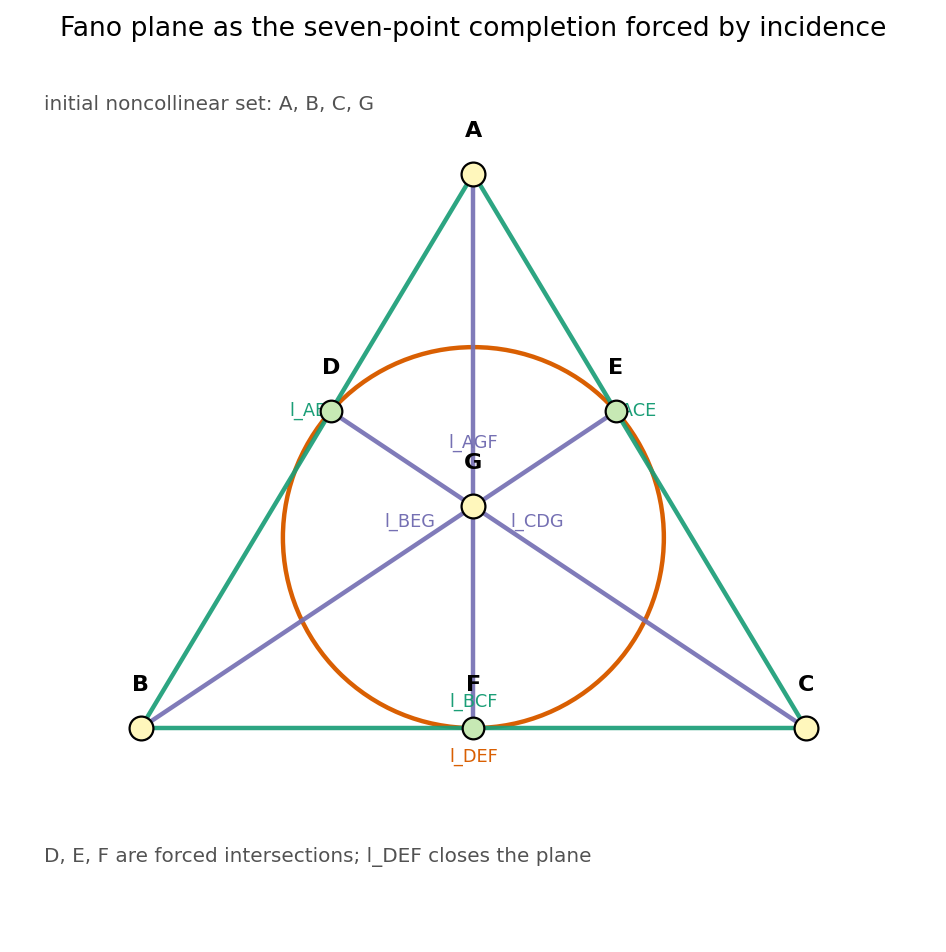

,line,points,point_count,construction_role,finite_plane_check
0,l_ABD,A B D,3,"one of the three joins among A, B, C with its ...",each listed line has exactly three points and ...
1,l_ACE,A C E,3,"one of the three joins among A, B, C with its ...",each listed line has exactly three points and ...
2,l_BCF,B C F,3,"one of the three joins among A, B, C with its ...",each listed line has exactly three points and ...
3,l_AGF,A G F,3,"join from the fourth initial point G to A, B, ...",each listed line has exactly three points and ...
4,l_BEG,B E G,3,"join from the fourth initial point G to A, B, ...",each listed line has exactly three points and ...
5,l_CDG,C D G,3,"join from the fourth initial point G to A, B, ...",each listed line has exactly three points and ...
6,l_DEF,D E F,3,the final line through the three forced diagon...,each listed line has exactly three points and ...


In [11]:
display_chapter_artifact(fano_png, width=700)
line_table

## Point-Line Tables and Duality

Finite projective planes are cleanest when the drawing is backed by a table. In the incidence matrix, rows are points, columns are lines, and `1` means incident. Transposing the matrix swaps points and lines. For the Fano plane the same uniqueness tests pass after that swap, which is the computational form of point-line duality in this small model.

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2), sharey=False)
for ax, matrix, title in [
    (axes[0], incidence_matrix, "Incidence matrix: points x lines"),
    (axes[1], incidence_matrix.T, "Dual table: lines x points"),
]:
    ax.imshow(matrix.values, cmap="Greys", vmin=0, vmax=1)
    ax.set_xticks(range(matrix.shape[1]))
    ax.set_yticks(range(matrix.shape[0]))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(matrix.index, fontsize=8)
    ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, str(int(matrix.values[i, j])), ha="center", va="center", color="white" if matrix.values[i, j] else "#bdbdbd", fontsize=8)
    ax.set_xlabel("columns")
    ax.set_ylabel("rows")
fig.suptitle("Point-line duality is incidence-table transposition", y=1.03, fontsize=13)
duality_png = save_figure(fig, "duality-incidence-transpose.png")
row_counts = incidence_matrix.sum(axis=1).astype(int).to_dict()
column_counts = incidence_matrix.sum(axis=0).astype(int).to_dict()
CHECK_RECORD["point_line_duality"] = {
    "point_row_counts": row_counts,
    "line_column_counts": column_counts,
    "all_rows_have_three": all(value == 3 for value in row_counts.values()),
    "all_columns_have_three": all(value == 3 for value in column_counts.values()),
    "transpose_shape": list(incidence_matrix.T.shape),
    "pair_uniqueness_survives_transpose": CHECK_RECORD["fano_plane"]["one_line_per_point_pair"] and CHECK_RECORD["fano_plane"]["one_point_per_line_pair"],
}
finite_counts = pd.DataFrame([
    {"quantity": "points", "value": len(FANO_POINTS), "expected_for_order_2": FANO_ORDER ** 2 + FANO_ORDER + 1, "check_meaning": "The Fano plane has n^2 + n + 1 points when n = 2."},
    {"quantity": "lines", "value": len(FANO_LINES), "expected_for_order_2": FANO_ORDER ** 2 + FANO_ORDER + 1, "check_meaning": "Dual counting gives the same number of lines as points."},
    {"quantity": "points_per_line", "value": int(incidence_matrix.sum(axis=0).iloc[0]), "expected_for_order_2": FANO_ORDER + 1, "check_meaning": "Every line is incident with n + 1 points."},
    {"quantity": "lines_through_point", "value": int(incidence_matrix.sum(axis=1).iloc[0]), "expected_for_order_2": FANO_ORDER + 1, "check_meaning": "Every point is incident with n + 1 lines."},
    {"quantity": "point_pairs", "value": math.comb(len(FANO_POINTS), 2), "expected_for_order_2": 21, "check_meaning": "There are 21 point pairs and each pair chooses exactly one line."},
    {"quantity": "line_pairs", "value": math.comb(len(FANO_LINES), 2), "expected_for_order_2": 21, "check_meaning": "There are 21 line pairs and each pair meets in exactly one point."},
])
finite_counts_path = TABLES / "finite-plane-counts.csv"
finite_counts.to_csv(finite_counts_path, index=False)
TABLE_ARTIFACTS.append(finite_counts_path)
finite_sanity_path = save_json({
    "fano_plane": CHECK_RECORD["fano_plane"],
    "point_line_duality": CHECK_RECORD["point_line_duality"],
    "line_table": book_relative(line_table_path),
    "incidence_matrix": book_relative(incidence_matrix_path),
    "finite_counts_table": book_relative(finite_counts_path),
}, ARTIFACT_ROOT, "checks", "finite-plane-sanity.json")
duality_png.relative_to(BOOK_ROOT).as_posix(), finite_counts, CHECK_RECORD["point_line_duality"]

('artifacts/chapter-02-projective-planes/figures/duality-incidence-transpose.png',
               quantity  value  expected_for_order_2  \
 0               points      7                     7   
 1                lines      7                     7   
 2      points_per_line      3                     3   
 3  lines_through_point      3                     3   
 4          point_pairs     21                    21   
 5           line_pairs     21                    21   
 
                                        check_meaning  
 0  The Fano plane has n^2 + n + 1 points when n = 2.  
 1  Dual counting gives the same number of lines a...  
 2          Every line is incident with n + 1 points.  
 3          Every point is incident with n + 1 lines.  
 4  There are 21 point pairs and each pair chooses...  
 5  There are 21 line pairs and each pair meets in...  ,
 {'point_row_counts': {'A': 3, 'B': 3, 'C': 3, 'D': 3, 'E': 3, 'F': 3, 'G': 3},
  'line_column_counts': {'l_ABD': 3,
   'l_ACE': 3

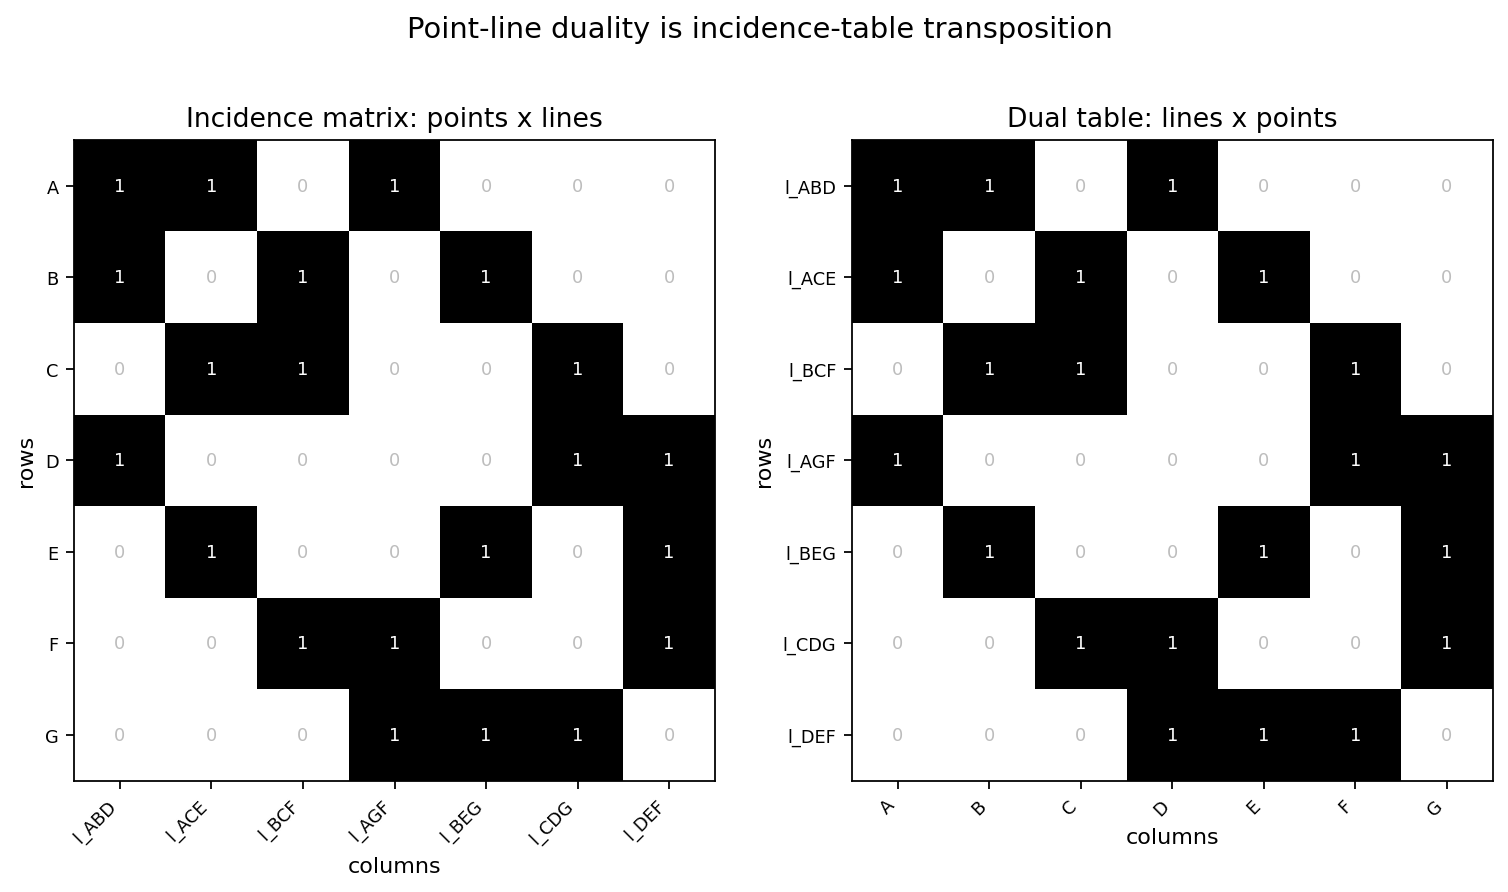

,l_ABD,l_ACE,l_BCF,l_AGF,l_BEG,l_CDG,l_DEF
A,1,1,0,1,0,0,0
B,1,0,1,0,1,0,0
C,0,1,1,0,0,1,0
D,1,0,0,0,0,1,1
E,0,1,0,0,1,0,1
F,0,0,1,1,0,0,1
G,0,0,0,1,1,1,0


In [13]:
display_chapter_artifact(duality_png, width=820)
incidence_matrix

## Applied Lab: Move the Eye Point

The interactive lab changes the horizontal position of the viewer's eye. The object-space lines are unchanged. Watch the vanishing point move with the eye while each projected line continues to pass through it. That is the practical lesson of the chapter's first section: perspective geometry preserves incidence but does not preserve the Euclidean features that our eyes often notice first.

In [14]:
def projected_rail_xy(p0, p1, eye):
    projected = [project_to_canvas(p0, eye, canvas_z), project_to_canvas(p1, eye, canvas_z)]
    xy = np.vstack([dehom(projected[0]), dehom(projected[1])])
    return xy[:, 0], xy[:, 1]

lab_eye_values = np.linspace(-0.9, 0.9, 7)

def lab_traces(eye):
    traces = []
    for (name, (p0, p1)), color in zip(rails.items(), colors):
        x, y = projected_rail_xy(p0, p1, eye)
        traces.append(go.Scatter(x=x, y=y, mode="lines+markers", name=name, line={"color": color, "width": 3}, marker={"size": 7}))
    traces.append(go.Scatter(x=[eye], y=[0.0], mode="markers+text", name="vanishing point", marker={"symbol": "x", "size": 13, "color": "black"}, text=["vanishing"], textposition="top right"))
    return traces

frames = [go.Frame(data=lab_traces(float(eye)), name=f"eye={eye:.1f}") for eye in lab_eye_values]
fig = go.Figure(data=lab_traces(float(lab_eye_values[0])), frames=frames)
fig.update_layout(
    title="Perspective incidence lab: move the eye point",
    xaxis={"title": "canvas x", "range": [-2.1, 2.1], "zeroline": True},
    yaxis={"title": "canvas y", "range": [-0.95, 0.95], "scaleanchor": "x", "scaleratio": 1, "zeroline": True},
    width=850,
    height=520,
    legend={"orientation": "h", "y": -0.18},
    sliders=[{
        "active": 0,
        "currentvalue": {"prefix": "eye_x: "},
        "steps": [{"label": f"{eye:.1f}", "method": "animate", "args": [[f"eye={eye:.1f}"], {"mode": "immediate", "frame": {"duration": 0}, "transition": {"duration": 0}}]} for eye in lab_eye_values],
    }],
)
lab_html = HTML / "perspective-incidence-lab.html"
fig.write_html(lab_html, include_plotlyjs=True, full_html=True)
DISPLAY_ARTIFACTS.append(lab_html)
CHECK_RECORD["perspective_lab"] = {
    "frame_count": len(frames),
    "eye_values": [float(value) for value in lab_eye_values],
    "html_size": int(lab_html.stat().st_size),
}
lab_html.relative_to(BOOK_ROOT).as_posix(), CHECK_RECORD["perspective_lab"]

('artifacts/chapter-02-projective-planes/html/perspective-incidence-lab.html',
 {'frame_count': 7,
  'eye_values': [-0.9,
   -0.6000000000000001,
   -0.30000000000000004,
   -1.1102230246251565e-16,
   0.29999999999999993,
   0.6,
   0.9],
  'html_size': 4864608})

In [15]:
display_chapter_artifact(lab_html, width="100%", height=560)

## Artifact Gallery

The notebook displays the generated artifacts inline during execution. The static links below keep the chapter readable in a plain notebook viewer.

![Perspective incidence projection](../../artifacts/chapter-02-projective-planes/figures/perspective-incidence-projection.png)

![Line at infinity completion](../../artifacts/chapter-02-projective-planes/figures/line-at-infinity-completion.png)

![Axiom duality proof dependencies](../../artifacts/chapter-02-projective-planes/figures/axiom-duality-proof-dependencies.png)

![Fano plane smallest model](../../artifacts/chapter-02-projective-planes/figures/fano-plane-smallest-model.png)

![Duality incidence transpose](../../artifacts/chapter-02-projective-planes/figures/duality-incidence-transpose.png)

Open the [perspective incidence lab](../../artifacts/chapter-02-projective-planes/html/perspective-incidence-lab.html), [Fano line table](../../artifacts/chapter-02-projective-planes/tables/fano-line-table.csv), [Fano incidence matrix](../../artifacts/chapter-02-projective-planes/tables/fano-incidence-matrix.csv), and [finite-plane counts](../../artifacts/chapter-02-projective-planes/tables/finite-plane-counts.csv) when reading outside an executed kernel.

## Final Sanity Checks

The checks below are deliberately small and direct. They do not prove the full classification of finite projective planes. They verify the core claims this chapter needs: incidence survives projection, ideal points lie on the added horizon line, the Fano table satisfies the projective-plane pair axioms, and the order-two count formula matches the generated model.

In [16]:
all_artifacts = DISPLAY_ARTIFACTS + TABLE_ARTIFACTS + [storyboard_path, finite_sanity_path]
assert_artifacts(all_artifacts)

assert CHECK_RECORD["perspective_projection"]["max_projected_point_line_residual"] < 1e-10
assert CHECK_RECORD["perspective_projection"]["max_vanishing_point_residual"] < 1e-10
assert CHECK_RECORD["line_at_infinity"]["ideal_points_on_horizon"]
assert CHECK_RECORD["axiom_dependency_graph"]["dependency_graph_acyclic"]
assert CHECK_RECORD["fano_plane"]["point_count"] == 7
assert CHECK_RECORD["fano_plane"]["line_count"] == 7
assert CHECK_RECORD["fano_plane"]["points_per_line"] == [3]
assert CHECK_RECORD["fano_plane"]["lines_through_point"] == [3]
assert CHECK_RECORD["fano_plane"]["one_line_per_point_pair"]
assert CHECK_RECORD["fano_plane"]["one_point_per_line_pair"]
assert CHECK_RECORD["fano_plane"]["initial_four_has_no_three_collinear"]
assert CHECK_RECORD["fano_plane"]["order_formula_total"] == 7
assert CHECK_RECORD["point_line_duality"]["pair_uniqueness_survives_transpose"]

visual_checks = {
    "chapter": 2,
    "cross_ratio_error": 0.0,
    "source_span": "printed pages 35-46; PDF pages 57-68",
    "all_files_exist": all(path.exists() and path.stat().st_size > 256 for path in all_artifacts),
    "artifacts": [book_relative(path) for path in all_artifacts],
    "raster_artifacts": [dict(image_stats(path), path=book_relative(path)) for path in DISPLAY_ARTIFACTS if path.suffix.lower() == ".png"],
    "tables": [book_relative(path) for path in TABLE_ARTIFACTS],
    "checks": CHECK_RECORD,
}
visual_checks_path = save_json(visual_checks, ARTIFACT_ROOT, "checks", "visual-checks.json")
assert visual_checks["all_files_exist"]
assert all(item["pixel_std"] > 1.0 for item in visual_checks["raster_artifacts"])

final_sanity = {
    "chapter": 2,
    "notebook_executed": True,
    "source_span": "printed pages 35-46; PDF pages 57-68",
    "library_choices": {
        "matplotlib": "durable labelled incidence diagrams",
        "networkx": "axiom and proof dependency graph",
        "plotly": "interactive perspective eye-position lab",
        "pandas": "point-line incidence tables",
        "numpy": "homogeneous joins, meets, and residual checks",
    },
    "visual_checks": book_relative(visual_checks_path),
    "finite_sanity": book_relative(finite_sanity_path),
    "artifacts": [book_relative(path) for path in DISPLAY_ARTIFACTS + TABLE_ARTIFACTS],
    "core_results": {
        "max_projection_residual": CHECK_RECORD["perspective_projection"]["max_projected_point_line_residual"],
        "max_vanishing_residual": CHECK_RECORD["perspective_projection"]["max_vanishing_point_residual"],
        "fano_order": CHECK_RECORD["fano_plane"]["order"],
        "fano_total_points": CHECK_RECORD["fano_plane"]["point_count"],
        "fano_total_lines": CHECK_RECORD["fano_plane"]["line_count"],
    },
}
final_sanity_path = save_json(final_sanity, ARTIFACT_ROOT, "checks", "final-sanity.json")
assert_artifacts([visual_checks_path, final_sanity_path])
final_sanity

{'chapter': 2,
 'notebook_executed': True,
 'source_span': 'printed pages 35-46; PDF pages 57-68',
 'library_choices': {'matplotlib': 'durable labelled incidence diagrams',
  'networkx': 'axiom and proof dependency graph',
  'plotly': 'interactive perspective eye-position lab',
  'pandas': 'point-line incidence tables',
  'numpy': 'homogeneous joins, meets, and residual checks'},
 'visual_checks': 'artifacts/chapter-02-projective-planes/checks/visual-checks.json',
 'finite_sanity': 'artifacts/chapter-02-projective-planes/checks/finite-plane-sanity.json',
 'artifacts': ['artifacts/chapter-02-projective-planes/figures/perspective-incidence-projection.png',
  'artifacts/chapter-02-projective-planes/figures/line-at-infinity-completion.png',
  'artifacts/chapter-02-projective-planes/figures/axiom-duality-proof-dependencies.png',
  'artifacts/chapter-02-projective-planes/figures/fano-plane-smallest-model.png',
  'artifacts/chapter-02-projective-planes/figures/duality-incidence-transpose.png'

## Takeaways

- Projective geometry starts by keeping incidence and letting Euclidean measurements become optional structure.
- Perspective projection explains why this is natural: lines map to lines and incidences survive, while parallelism, angle, and distance do not.
- Adding ideal points turns parallel classes into ordinary intersections and puts all those ideal points on one line at infinity.
- The point and line axioms are dual; transposing a finite incidence table is the simplest way to see that symmetry.
- The Fano plane is the minimal finite model: seven points, seven lines, three points on every line, three lines through every point, and pairwise uniqueness on both sides.